# 🤟 SignSense AI — Data Collection Pipeline
### ASL Sign Language Recognition | MediaPipe 0.10.30 | Python 3.10.11
---
**Run every cell top-to-bottom. Do NOT skip any cell.**  
**Kernel:** `SignSense AI (Python 3.10)` — verify in VS Code bottom-right corner.

| Cell | Purpose |
|------|---------|
| 1 | Verify environment |
| 2 | Imports |
| 3 | Configuration |
| 4 | MediaPipe setup & helper functions |
| 5 | Create folder structure |
| 6 | Camera test |
| 7 | Data collection (main loop) |
| 8 | Dataset verification |


## ✅ Cell 1 — Verify Environment

In [2]:
import sys
import importlib
import subprocess

print("=" * 60)
print("  SignSense AI — Environment Verification")
print("=" * 60)
print(f"  Python : {sys.version}")
print()

REQUIRED = {
    "cv2"        : ("opencv-python",  "4.0.0"),
    "mediapipe"  : ("mediapipe",      "0.10.0"),
    "numpy"      : ("numpy",          "1.20.0"),
    "tensorflow" : ("tensorflow",     "2.10.0"),
    "matplotlib" : ("matplotlib",     "3.0.0"),
    "sklearn"    : ("scikit-learn",   "0.20.0"),
    "tqdm"       : ("tqdm",           "4.0.0"),
}

all_ok = True
for module, (pkg, min_ver) in REQUIRED.items():
    try:
        mod = importlib.import_module(module)
        ver = getattr(mod, "__version__", "unknown")
        print(f"  ✅  {module:<15} {ver}")
    except ImportError:
        print(f"  ❌  {module:<15} NOT INSTALLED")
        print(f"       Fix: pip install {pkg}")
        all_ok = False

print()
if all_ok:
    print("  🎉  All packages ready. Proceed to Cell 2.")
else:
    print("  ⚠️   Install missing packages in terminal (with signsense_env active)")
    print("      pip install opencv-python mediapipe tensorflow numpy")
    print("      pip install matplotlib scikit-learn tqdm")
print("=" * 60)


  SignSense AI — Environment Verification
  Python : 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]

  ✅  cv2             4.10.0
  ✅  mediapipe       0.10.21
  ✅  numpy           1.26.4
  ✅  tensorflow      2.18.0
  ✅  matplotlib      3.10.9
  ✅  sklearn         1.7.2
  ✅  tqdm            4.68.2

  🎉  All packages ready. Proceed to Cell 2.


In [1]:
import sys
import mediapipe as mp

print(sys.executable)
print(mp.__version__)

with mp.solutions.hands.Hands() as hands:
    print("SUCCESS")

d:\Downloads\data_collection\signsense_env\Scripts\python.exe
0.10.21
SUCCESS


## 📚 Cell 2 — Imports

In [3]:
import os
import cv2
import sys
import time
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

# ── MediaPipe Solutions (still available in 0.10.30) ──────────────────────────
# NOTE: mp.solutions.holistic is BROKEN in 0.10.30
# We use mp.solutions.hands + mp.solutions.pose instead — both work perfectly
mp_hands          = mp.solutions.hands
mp_pose           = mp.solutions.pose
mp_drawing        = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

# ── ML ────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils  import to_categorical

print("=" * 60)
print("  SignSense AI — Imports")
print("=" * 60)
print(f"  OpenCV     : {cv2.__version__}")
print(f"  MediaPipe  : {mp.__version__}")
print(f"  NumPy      : {np.__version__}")
import tensorflow as tf
print(f"  TensorFlow : {tf.__version__}")
print()
print("  ✅  All imports successful.")
print("=" * 60)


  SignSense AI — Imports
  OpenCV     : 4.10.0
  MediaPipe  : 0.10.21
  NumPy      : 1.26.4
  TensorFlow : 2.18.0

  ✅  All imports successful.


## ⚙️ Cell 3 — Configuration
> **This is the only cell you need to customize.**  
> `PROJECT_DIR` must match your exact folder path.


In [5]:
# ╔══════════════════════════════════════════════════════════╗
# ║              SIGNSENSE AI — CONFIGURATION                ║
# ╚══════════════════════════════════════════════════════════╝

# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_DIR = r"D:\Downloads\data_collection"
DATA_PATH   = os.path.join(PROJECT_DIR, "MP_Data")

# ── ASL Gesture Classes ───────────────────────────────────────────────────────
# These are your 10 ASL signs. Add/remove freely — model adapts automatically.
ASL_ACTIONS = np.array([
    "hello",
    "thank_you",
    "please",
    "yes",
    "no",
    "sorry",
    "help",
    "good",
    "bad",
    "stop"
])

# ── Collection Parameters ─────────────────────────────────────────────────────
NO_SEQUENCES    = 150   # Sequences (videos) per class — DO NOT reduce below 100
SEQUENCE_LENGTH = 30    # Frames per sequence — must stay 30 (model depends on this)
PREP_TIME       = 3     # Countdown seconds before each sequence starts
SEQUENCE_GAP    = 0.4   # Seconds between sequences (prevents blur between signs)

# ── MediaPipe Confidence ──────────────────────────────────────────────────────
MIN_HAND_DETECTION = 0.7
MIN_HAND_TRACKING  = 0.5
MIN_POSE_DETECTION = 0.6
MIN_POSE_TRACKING  = 0.5

# ── Webcam ────────────────────────────────────────────────────────────────────
CAMERA_INDEX = 0  # 0 = built-in webcam. Change to 1 for external USB webcam.

# ── Feature Vector ────────────────────────────────────────────────────────────
# pose (33×4=132) + face_zeros (468×3=1404) + lh (21×3=63) + rh (21×3=63) = 1662
FEATURE_SIZE = 1662

# ── Summary ───────────────────────────────────────────────────────────────────
total_seqs   = len(ASL_ACTIONS) * NO_SEQUENCES
total_frames = total_seqs * SEQUENCE_LENGTH
est_min      = (total_seqs * (SEQUENCE_LENGTH / 20 + SEQUENCE_GAP) +
                len(ASL_ACTIONS) * PREP_TIME) / 60

print("=" * 60)
print("  SignSense AI — Collection Configuration")
print("=" * 60)
print(f"  Classes          : {len(ASL_ACTIONS)}")
print(f"  Signs            : {', '.join(ASL_ACTIONS)}")
print(f"  Sequences/class  : {NO_SEQUENCES}")
print(f"  Frames/sequence  : {SEQUENCE_LENGTH}")
print(f"  Feature size     : {FEATURE_SIZE}")
print(f"  Total sequences  : {total_seqs:,}")
print(f"  Total frames     : {total_frames:,}")
print(f"  Estimated time   : ~{est_min:.0f} minutes")
print(f"  Save path        : {DATA_PATH}")
print("=" * 60)

# Validate project dir exists
if os.path.exists(PROJECT_DIR):
    print(f"  ✅  Project directory found.")
else:
    print(f"  ❌  Project directory NOT found: {PROJECT_DIR}")
    print(f"      Create it or update PROJECT_DIR above.")


  SignSense AI — Collection Configuration
  Classes          : 10
  Signs            : hello, thank_you, please, yes, no, sorry, help, good, bad, stop
  Sequences/class  : 150
  Frames/sequence  : 30
  Feature size     : 1662
  Total sequences  : 1,500
  Total frames     : 45,000
  Estimated time   : ~48 minutes
  Save path        : D:\Downloads\data_collection\MP_Data
  ✅  Project directory found.


## 🤖 Cell 4 — MediaPipe Setup & Helper Functions
Uses `mp.solutions.hands` + `mp.solutions.pose` (both work in MediaPipe 0.10.30).  
**NOT using `mp.solutions.holistic`** — that is broken in 0.10.30.


In [6]:
# ── Drawing Specs ─────────────────────────────────────────────────────────────
HAND_DOT   = mp_drawing.DrawingSpec(color=(0, 255, 180),  thickness=2, circle_radius=4)
HAND_LINE  = mp_drawing.DrawingSpec(color=(0, 200, 255),  thickness=2, circle_radius=2)
POSE_DOT   = mp_drawing.DrawingSpec(color=(255, 120, 30), thickness=2, circle_radius=3)
POSE_LINE  = mp_drawing.DrawingSpec(color=(200, 80,  0),  thickness=2, circle_radius=2)


# ─────────────────────────────────────────────────────────────────────────────
def detect_landmarks(frame_bgr, hand_detector, pose_detector):
    """
    Run hand + pose detection on a single BGR frame.

    Args:
        frame_bgr     : OpenCV BGR frame from webcam
        hand_detector : mp.solutions.hands.Hands instance
        pose_detector : mp.solutions.pose.Pose instance

    Returns:
        hand_results  : MediaPipe hand detection results
        pose_results  : MediaPipe pose detection results
        annotated     : Copy of frame ready for drawing
    """
    # MediaPipe requires RGB
    rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    rgb.flags.writeable = False          # Performance: prevent copy in mediapipe

    hand_results = hand_detector.process(rgb)
    pose_results = pose_detector.process(rgb)

    rgb.flags.writeable = True
    return hand_results, pose_results, frame_bgr.copy()


# ─────────────────────────────────────────────────────────────────────────────
def draw_landmarks(frame, hand_results, pose_results):
    """
    Draw hand and pose landmarks on frame using mp.solutions drawing utilities.
    """
    # ── Pose skeleton ─────────────────────────────────────────────────────────
    if pose_results.pose_landmarks:
        mp_drawing.draw_landmarks(
            frame,
            pose_results.pose_landmarks,
            mp_pose.POSE_CONNECTIONS,
            POSE_DOT,
            POSE_LINE
        )

    # ── Hand landmarks (supports 0, 1, or 2 hands) ───────────────────────────
    if hand_results.multi_hand_landmarks:
        for hand_lms in hand_results.multi_hand_landmarks:
            mp_drawing.draw_landmarks(
                frame,
                hand_lms,
                mp_hands.HAND_CONNECTIONS,
                HAND_DOT,
                HAND_LINE
            )

    return frame


# ─────────────────────────────────────────────────────────────────────────────
def extract_keypoints(hand_results, pose_results):
    """
    Extract and flatten all landmarks into a fixed 1662-dimensional vector.

    Vector layout (must stay consistent — model trained on this shape):
        [0   : 132 ] Pose  — 33 landmarks × 4 (x, y, z, visibility)
        [132 : 1536] Face  — 468 × 3 = 1404 zeros (face not needed for ASL)
        [1536: 1599] Left hand  — 21 × 3 (x, y, z)
        [1599: 1662] Right hand — 21 × 3 (x, y, z)

    Zero-padding is applied when any body part is not detected,
    ensuring consistent vector shape for every frame.
    """
    # ── Pose (33 landmarks × 4 values) ───────────────────────────────────────
    if pose_results.pose_landmarks:
        pose = np.array([
            [lm.x, lm.y, lm.z, lm.visibility]
            for lm in pose_results.pose_landmarks.landmark
        ]).flatten()
    else:
        pose = np.zeros(33 * 4)  # 132

    # ── Face (zeros — not used for hand-sign ASL) ─────────────────────────────
    face = np.zeros(468 * 3)     # 1404

    # ── Hands ─────────────────────────────────────────────────────────────────
    lh = np.zeros(21 * 3)
    rh = np.zeros(21 * 3)

    if hand_results.multi_hand_landmarks and hand_results.multi_handedness:
        for hand_lms, handedness in zip(
            hand_results.multi_hand_landmarks,
            hand_results.multi_handedness
        ):
            coords = np.array(
                [[lm.x, lm.y, lm.z] for lm in hand_lms.landmark]
            ).flatten()

            # MediaPipe flips handedness for mirrored (selfie) camera
            label = handedness.classification[0].label
            if label == "Left":
                lh = coords
            else:
                rh = coords

    return np.concatenate([pose, face, lh, rh])  # shape: (1662,)


# ─────────────────────────────────────────────────────────────────────────────
def count_hands(hand_results):
    """Returns number of detected hands (0, 1, or 2)."""
    if hand_results.multi_hand_landmarks:
        return len(hand_results.multi_hand_landmarks)
    return 0


# ─────────────────────────────────────────────────────────────────────────────
def draw_hud(frame, action, seq_idx, frame_idx, total_seqs, n_hands, fps, phase):
    """
    Draw a clean information HUD on the collection frame.

    phase: "countdown" | "collecting" | "pause"
    """
    h, w = frame.shape[:2]

    # ── Top dark bar ──────────────────────────────────────────────────────────
    cv2.rectangle(frame, (0, 0), (w, 100), (8, 10, 22), -1)

    # App name
    cv2.putText(frame, "SIGNSENSE AI",
                (12, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0, 220, 180), 2)
    cv2.putText(frame, "DATA COLLECTION",
                (12, 55), cv2.FONT_HERSHEY_SIMPLEX, 0.50, (120, 120, 180), 1)

    # Action label (large, centered)
    label  = action.replace("_", " ").upper()
    (tw, _), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 1.1, 3)
    cv2.putText(frame, label,
                (w // 2 - tw // 2, 48),
                cv2.FONT_HERSHEY_SIMPLEX, 1.1, (0, 255, 200), 3)

    # Top-right counters
    cv2.putText(frame,
                f"Seq {seq_idx+1}/{total_seqs}   Frame {frame_idx+1}/{SEQUENCE_LENGTH}",
                (w - 345, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.52, (200, 200, 200), 1)
    cv2.putText(frame, f"FPS: {fps:.0f}   Hands: {n_hands}",
                (w - 235, 54), cv2.FONT_HERSHEY_SIMPLEX, 0.50, (140, 140, 140), 1)

    # ── Progress bar ──────────────────────────────────────────────────────────
    bx, by, bw, bh = 10, 85, w - 20, 9
    filled = int(bw * seq_idx / max(total_seqs, 1))
    cv2.rectangle(frame, (bx, by), (bx + bw, by + bh), (35, 35, 55), -1)
    cv2.rectangle(frame, (bx, by), (bx + filled, by + bh), (0, 210, 150), -1)

    # ── Phase badge ───────────────────────────────────────────────────────────
    phase_cfg = {
        "countdown" : ((0, 160, 255), "COUNTDOWN"),
        "collecting": ((0, 220, 80),  "  RECORDING"),
        "pause"     : ((255, 160, 0), "    PAUSED"),
    }
    color, text = phase_cfg.get(phase, ((180, 180, 180), phase.upper()))
    cv2.rectangle(frame, (10, h - 52), (280, h - 12), (12, 12, 25), -1)
    cv2.putText(frame, f"● {text}",
                (18, h - 24), cv2.FONT_HERSHEY_SIMPLEX, 0.70, color, 2)

    # ── Hand status ───────────────────────────────────────────────────────────
    hc   = (0, 220, 80) if n_hands > 0 else (0, 60, 220)
    htxt = f"{n_hands} hand(s) detected" if n_hands > 0 else "No hand detected!"
    cv2.putText(frame, htxt,
                (w - 290, h - 24), cv2.FONT_HERSHEY_SIMPLEX, 0.58, hc, 2)

    return frame


print("=" * 60)
print("  MediaPipe helper functions ready.")
print(f"  Feature vector size : {FEATURE_SIZE}")
print(f"  Pose landmarks      : 33")
print(f"  Hand landmarks      : 21 per hand")
print(f"  Face slot           : zeros (not used for ASL)")
print("=" * 60)


  MediaPipe helper functions ready.
  Feature vector size : 1662
  Pose landmarks      : 33
  Hand landmarks      : 21 per hand
  Face slot           : zeros (not used for ASL)


## 📁 Cell 5 — Create Folder Structure
Safe to re-run — never overwrites existing data.

In [7]:
# ── Build directory tree ──────────────────────────────────────────────────────
# Structure: MP_Data / <action> / <sequence_id> / <frame_id>.npy
created = 0
skipped = 0

for action in ASL_ACTIONS:
    for seq_idx in range(NO_SEQUENCES):
        folder = os.path.join(DATA_PATH, action, str(seq_idx))
        if not os.path.exists(folder):
            os.makedirs(folder)
            created += 1
        else:
            skipped += 1

print("=" * 60)
print("  Folder Structure")
print("=" * 60)
print(f"  Root     : {DATA_PATH}")
print(f"  Created  : {created} new folders")
print(f"  Skipped  : {skipped} already existed")
print()
print("  Collection progress:")
for action in ASL_ACTIONS:
    action_path = os.path.join(DATA_PATH, action)
    # Count fully complete sequences
    complete = 0
    for seq_idx in range(NO_SEQUENCES):
        seq_path = os.path.join(action_path, str(seq_idx))
        n_files  = len([f for f in os.listdir(seq_path) if f.endswith(".npy")]) if os.path.exists(seq_path) else 0
        if n_files == SEQUENCE_LENGTH:
            complete += 1
    pct    = complete / NO_SEQUENCES * 100
    filled = int(pct / 5)
    bar    = "█" * filled + "░" * (20 - filled)
    print(f"  {action:<15} [{bar}] {complete}/{NO_SEQUENCES} ({pct:.0f}%)")
print("=" * 60)


  Folder Structure
  Root     : D:\Downloads\data_collection\MP_Data
  Created  : 0 new folders
  Skipped  : 1500 already existed

  Collection progress:
  hello           [░░░░░░░░░░░░░░░░░░░░] 0/150 (0%)
  thank_you       [░░░░░░░░░░░░░░░░░░░░] 0/150 (0%)
  please          [░░░░░░░░░░░░░░░░░░░░] 0/150 (0%)
  yes             [░░░░░░░░░░░░░░░░░░░░] 0/150 (0%)
  no              [░░░░░░░░░░░░░░░░░░░░] 0/150 (0%)
  sorry           [░░░░░░░░░░░░░░░░░░░░] 0/150 (0%)
  help            [░░░░░░░░░░░░░░░░░░░░] 0/150 (0%)
  good            [░░░░░░░░░░░░░░░░░░░░] 0/150 (0%)
  bad             [░░░░░░░░░░░░░░░░░░░░] 0/150 (0%)
  stop            [░░░░░░░░░░░░░░░░░░░░] 0/150 (0%)


## 📷 Cell 6 — Camera Test
**Run this before collection.** Confirms camera works and landmarks are detected.

**Checklist:**
- ✅ Camera feed opens in a new window
- ✅ Green dots + lines appear on your hands
- ✅ Orange skeleton appears on your body
- ✅ "X hand(s) detected" shows green when hands are visible

Press **`Q`** to close the preview.


In [8]:
print("Opening 15-second camera preview...")
print("Show your hand to the camera. Press Q to exit early.")
print()

cap = cv2.VideoCapture(CAMERA_INDEX)
if not cap.isOpened():
    raise RuntimeError(
        f"Cannot open camera at index {CAMERA_INDEX}.\n"
        f"Try changing CAMERA_INDEX to 1 in Cell 3."
    )

cap.set(cv2.CAP_PROP_FRAME_WIDTH,  1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

start_t    = time.time()
frame_cnt  = 0
fps_display = 0.0
fps_clock  = time.time()

with mp_hands.Hands(
    max_num_hands=2,
    min_detection_confidence=MIN_HAND_DETECTION,
    min_tracking_confidence=MIN_HAND_TRACKING
) as hand_det, mp_pose.Pose(
    min_detection_confidence=MIN_POSE_DETECTION,
    min_tracking_confidence=MIN_POSE_TRACKING
) as pose_det:

    while True:
        ret, frame = cap.read()
        if not ret:
            print("⚠️  Frame read failed. Check camera connection.")
            break

        frame = cv2.flip(frame, 1)   # Mirror for natural (selfie) interaction
        hand_res, pose_res, annotated = detect_landmarks(frame, hand_det, pose_det)
        annotated = draw_landmarks(annotated, hand_res, pose_res)

        # FPS
        frame_cnt += 1
        if frame_cnt % 15 == 0:
            fps_display = 15 / (time.time() - fps_clock)
            fps_clock   = time.time()

        elapsed  = time.time() - start_t
        n_hands  = count_hands(hand_res)
        detected = n_hands > 0

        # HUD
        cv2.rectangle(annotated, (0, 0), (480, 95), (10, 12, 25), -1)
        cv2.putText(annotated, "SIGNSENSE AI  |  CAMERA TEST",
                    (12, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.70, (0, 220, 180), 2)
        cv2.putText(annotated, f"FPS: {fps_display:.1f}   Hands detected: {n_hands}",
                    (12, 58), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (200, 200, 200), 1)

        hcolor = (0, 220, 80) if detected else (0, 60, 220)
        htext  = "✓  Landmarks ACTIVE — ready to collect!" if detected else "✗  No hand visible — show your hand"
        cv2.putText(annotated, htext,
                    (12, 83), cv2.FONT_HERSHEY_SIMPLEX, 0.52, hcolor, 2)

        cv2.putText(annotated,
                    f"Press Q to close  |  {elapsed:.0f}s / 15s",
                    (12, annotated.shape[0] - 15),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (100, 100, 100), 1)

        cv2.imshow("SignSense AI — Camera Test", annotated)

        if cv2.waitKey(1) & 0xFF == ord("q") or elapsed > 15:
            break

cap.release()
cv2.destroyAllWindows()
time.sleep(0.3)  # Allow window to close cleanly

total_elapsed = time.time() - start_t
print(f"✅ Camera test complete.")
print(f"   Frames captured : {frame_cnt}")
print(f"   Avg FPS         : {frame_cnt / max(total_elapsed, 1):.1f}")
print()
print("  If you saw landmarks → you are READY for Cell 7 (data collection).")
print("  If no landmarks   → improve lighting and position hand closer.")


Opening 15-second camera preview...
Show your hand to the camera. Press Q to exit early.

✅ Camera test complete.
   Frames captured : 233
   Avg FPS         : 14.8

  If you saw landmarks → you are READY for Cell 7 (data collection).
  If no landmarks   → improve lighting and position hand closer.


## 🎬 Cell 7 — Data Collection (Main Loop)

### What happens automatically:
1. For each sign → **3-second countdown** (get into position)
2. Perform the sign → script captures **150 sequences × 30 frames**
3. Short pause between sequences → next countdown → repeat
4. Script moves to next sign automatically

### Controls:
- **`P`** → Pause / Resume anytime
- **`Q`** → Quit (all progress is saved — re-run this cell to resume)

### Tips for best model accuracy:
- 💡 Good lighting — face a window or lamp
- ✋ Keep your signing hand clearly in frame
- 🔄 Vary your angle/distance slightly between sequences (don't be robotic)
- ↔️ Try both slightly left/right variations across sequences


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
def check_resume_point(action):
    """
    Find first incomplete sequence for this action.
    Enables seamless resume if collection is interrupted.
    Returns: index of first incomplete sequence (0 to NO_SEQUENCES)
    """
    action_path = os.path.join(DATA_PATH, action)
    for seq_idx in range(NO_SEQUENCES):
        seq_path  = os.path.join(action_path, str(seq_idx))
        if not os.path.exists(seq_path):
            return seq_idx
        n_saved = len([f for f in os.listdir(seq_path) if f.endswith(".npy")])
        if n_saved < SEQUENCE_LENGTH:
            return seq_idx
    return NO_SEQUENCES  # All complete


# ─────────────────────────────────────────────────────────────────────────────
def collect_action_sequences(hand_det, pose_det, cap, action, start_seq):
    """
    Collect all sequences for one ASL action class.

    Args:
        hand_det  : Active Hands detector context
        pose_det  : Active Pose detector context
        cap       : OpenCV VideoCapture
        action    : Action name string (e.g. "hello")
        start_seq : Resume from this sequence index

    Returns: "done" | "quit"
    """
    action_path = os.path.join(DATA_PATH, action)
    fps_clock, fps_cnt, fps_val = time.time(), 0, 0.0

    for seq_idx in range(start_seq, NO_SEQUENCES):

        # ── Countdown before each sequence ────────────────────────────────────
        countdown_start = time.time()
        while time.time() - countdown_start < PREP_TIME:
            ret, frame = cap.read()
            if not ret:
                continue
            frame = cv2.flip(frame, 1)
            hand_res, pose_res, annotated = detect_landmarks(frame, hand_det, pose_det)
            annotated = draw_landmarks(annotated, hand_res, pose_res)

            remaining = int(PREP_TIME - (time.time() - countdown_start)) + 1
            draw_hud(annotated, action, seq_idx, 0,
                     NO_SEQUENCES, count_hands(hand_res), fps_val, "countdown")

            # Large countdown number
            h_fr, w_fr = annotated.shape[:2]
            cv2.putText(annotated, str(remaining),
                        (w_fr // 2 - 45, h_fr // 2 + 40),
                        cv2.FONT_HERSHEY_SIMPLEX, 5.0, (0, 220, 180), 10)

            cv2.imshow("SignSense AI — Data Collection", annotated)
            if cv2.waitKey(1) & 0xFF == ord("q"):
                return "quit"

        # ── Frame collection loop ─────────────────────────────────────────────
        for frame_idx in range(SEQUENCE_LENGTH):
            ret, frame = cap.read()
            if not ret:
                print(f"  ⚠️  Frame skip @ seq={seq_idx} frame={frame_idx}")
                # Save zeros so sequence stays complete
                npy_path = os.path.join(action_path, str(seq_idx), str(frame_idx))
                np.save(npy_path, np.zeros(FEATURE_SIZE))
                continue

            frame = cv2.flip(frame, 1)
            hand_res, pose_res, annotated = detect_landmarks(frame, hand_det, pose_det)
            annotated = draw_landmarks(annotated, hand_res, pose_res)

            # ── Extract and save keypoints immediately ─────────────────────────
            keypoints = extract_keypoints(hand_res, pose_res)
            npy_path  = os.path.join(action_path, str(seq_idx), str(frame_idx))
            np.save(npy_path, keypoints)

            # FPS tracker
            fps_cnt += 1
            if fps_cnt >= 15:
                fps_val  = fps_cnt / (time.time() - fps_clock)
                fps_clock = time.time()
                fps_cnt  = 0

            draw_hud(annotated, action, seq_idx, frame_idx,
                     NO_SEQUENCES, count_hands(hand_res), fps_val, "collecting")

            cv2.imshow("SignSense AI — Data Collection", annotated)

            key = cv2.waitKey(1) & 0xFF
            if key == ord("q"):
                return "quit"
            elif key == ord("p"):
                # ── Pause ─────────────────────────────────────────────────────
                print(f"  ⏸   Paused at seq={seq_idx}, frame={frame_idx}. Press P to resume.")
                while True:
                    ret2, f2 = cap.read()
                    if ret2:
                        f2 = cv2.flip(f2, 1)
                        draw_hud(f2, action, seq_idx, frame_idx,
                                 NO_SEQUENCES, 0, 0, "pause")
                        cv2.putText(f2, "PAUSED  —  Press P to resume",
                                    (f2.shape[1]//2 - 250, f2.shape[0]//2),
                                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 160, 0), 3)
                        cv2.imshow("SignSense AI — Data Collection", f2)
                    if cv2.waitKey(30) & 0xFF == ord("p"):
                        print(f"  ▶️   Resumed.")
                        break

        # Brief gap between sequences
        time.sleep(SEQUENCE_GAP)

    return "done"


# ════════════════════════════════════════════════════════════════════════════
#   MAIN COLLECTION LOOP
# ════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("  SignSense AI — Data Collection Starting")
print("=" * 60)
print()

# Open camera
cap = cv2.VideoCapture(CAMERA_INDEX)
if not cap.isOpened():
    raise RuntimeError(
        f"Cannot open camera at index {CAMERA_INDEX}.\n"
        f"Try changing CAMERA_INDEX to 1 in Cell 3."
    )
cap.set(cv2.CAP_PROP_FRAME_WIDTH,  1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

collection_log  = {}
session_start   = time.time()

with mp_hands.Hands(
    max_num_hands=2,
    min_detection_confidence=MIN_HAND_DETECTION,
    min_tracking_confidence=MIN_HAND_TRACKING
) as hand_det, mp_pose.Pose(
    min_detection_confidence=MIN_POSE_DETECTION,
    min_tracking_confidence=MIN_POSE_TRACKING
) as pose_det:

    for i, action in enumerate(ASL_ACTIONS):
        start_seq = check_resume_point(action)

        if start_seq >= NO_SEQUENCES:
            print(f"  ✅  [{i+1:02d}/{len(ASL_ACTIONS)}] '{action}' — already complete. Skipping.")
            collection_log[action] = "skipped"
            continue

        print(f"  🎬  [{i+1:02d}/{len(ASL_ACTIONS)}] Collecting: '{action.replace(chr(95), ' ').upper()}'")
        if start_seq > 0:
            print(f"       ↩️  Resuming from sequence {start_seq}/{NO_SEQUENCES}")

        result = collect_action_sequences(hand_det, pose_det, cap, action, start_seq)
        collection_log[action] = result

        if result == "quit":
            print(f"\n  ⛔  Collection stopped by user.")
            print(f"       Progress saved. Re-run Cell 7 to continue.")
            break
        else:
            print(f"  ✅  '{action}' — complete.")
        print()

cap.release()
cv2.destroyAllWindows()
time.sleep(0.3)

# ── Final Summary ─────────────────────────────────────────────────────────────
elapsed_total = time.time() - session_start
print()
print("=" * 60)
print(f"  Collection Summary  ({elapsed_total/60:.1f} minutes)")
print("=" * 60)
for action, status in collection_log.items():
    icon = "✅" if status in ("done", "skipped") else "⛔"
    print(f"  {icon}  {action:<15}  {status}")
print("=" * 60)
print()
print("  Next step: Run Cell 8 to verify your dataset.")


  SignSense AI — Data Collection Starting

  🎬  [01/10] Collecting: 'HELLO'
  ⏸   Paused at seq=17, frame=13. Press P to resume.
  ▶️   Resumed.
  ⏸   Paused at seq=60, frame=29. Press P to resume.
  ▶️   Resumed.
  ✅  'hello' — complete.

  🎬  [02/10] Collecting: 'THANK YOU'
  ⏸   Paused at seq=105, frame=6. Press P to resume.
  ▶️   Resumed.
  ✅  'thank_you' — complete.

  🎬  [03/10] Collecting: 'PLEASE'
  ⏸   Paused at seq=0, frame=4. Press P to resume.
  ▶️   Resumed.
  ⏸   Paused at seq=24, frame=1. Press P to resume.
  ▶️   Resumed.
  ⏸   Paused at seq=112, frame=4. Press P to resume.
  ▶️   Resumed.
  ✅  'please' — complete.

  🎬  [04/10] Collecting: 'YES'
  ⏸   Paused at seq=0, frame=5. Press P to resume.
  ▶️   Resumed.
  ✅  'yes' — complete.

  🎬  [05/10] Collecting: 'NO'
  ⏸   Paused at seq=0, frame=12. Press P to resume.
  ▶️   Resumed.
  ⏸   Paused at seq=42, frame=2. Press P to resume.
  ▶️   Resumed.
  ⏸   Paused at seq=49, frame=5. Press P to resume.
  ▶️   Resumed.
  ⏸

## ✅ Cell 8 — Dataset Verification
Verifies all `.npy` files are saved correctly and shows completion chart.

  SignSense AI — Dataset Verification Report
  hello            ✅ COMPLETE              missing frames: 0
  thank_you        ✅ COMPLETE              missing frames: 0
  please           ✅ COMPLETE              missing frames: 0
  yes              ✅ COMPLETE              missing frames: 0
  no               ✅ COMPLETE              missing frames: 0
  sorry            ✅ COMPLETE              missing frames: 0
  help             ✅ COMPLETE              missing frames: 0
  good             ✅ COMPLETE              missing frames: 0
  bad              ✅ COMPLETE              missing frames: 0
  stop             ✅ COMPLETE              missing frames: 0
  Total .npy files : 45,000
  Missing files    : 0
  Ready to train   : YES ✅  → Proceed to 02_train_model.ipynb

  Sample check: no/0/0.npy → shape (1662,) ✅


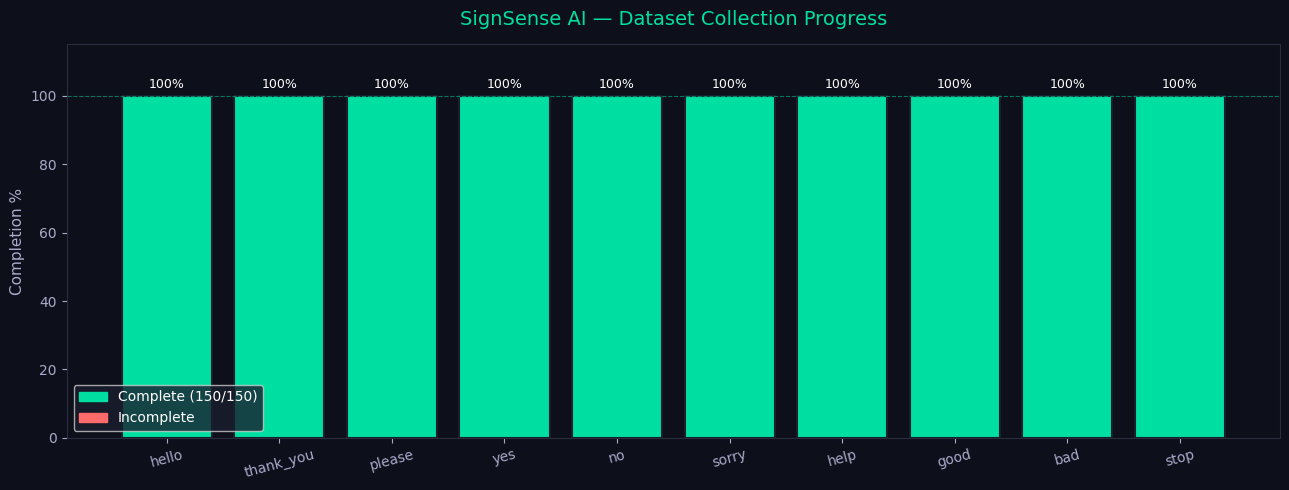


📊 Chart saved to: D:\Downloads\data_collection\dataset_progress.png


In [10]:
print("=" * 65)
print("  SignSense AI — Dataset Verification Report")
print("=" * 65)

total_files   = 0
total_missing = 0
report        = []

for action in ASL_ACTIONS:
    action_path   = os.path.join(DATA_PATH, action)
    complete_seqs = 0
    missing       = 0

    for seq_idx in range(NO_SEQUENCES):
        seq_path = os.path.join(action_path, str(seq_idx))
        found = 0
        for frame_idx in range(SEQUENCE_LENGTH):
            if os.path.exists(os.path.join(seq_path, f"{frame_idx}.npy")):
                found += 1
            else:
                missing += 1
        if found == SEQUENCE_LENGTH:
            complete_seqs += 1

    total_files   += complete_seqs * SEQUENCE_LENGTH
    total_missing += missing
    pct    = complete_seqs / NO_SEQUENCES * 100
    status = "✅ COMPLETE" if complete_seqs == NO_SEQUENCES else f"⚠️  {complete_seqs}/{NO_SEQUENCES}"
    report.append((action, complete_seqs, missing, pct, status))
    print(f"  {action:<15}  {status:<22}  missing frames: {missing}")

print("=" * 65)
print(f"  Total .npy files : {total_files:,}")
print(f"  Missing files    : {total_missing:,}")
ready = (total_missing == 0)
print(f"  Ready to train   : {'YES ✅  → Proceed to 02_train_model.ipynb' if ready else 'NO ⚠️  → Re-run Cell 7 to fill gaps'}")
print("=" * 65)

# ── Verify a random sample for shape integrity ─────────────────────────────────
import random
sample_action = random.choice(ASL_ACTIONS)
sample_npy    = os.path.join(DATA_PATH, sample_action, "0", "0.npy")
if os.path.exists(sample_npy):
    arr = np.load(sample_npy)
    shape_ok = arr.shape == (FEATURE_SIZE,)
    print(f"\n  Sample check: {sample_action}/0/0.npy → shape {arr.shape} {'✅' if shape_ok else '❌ WRONG SHAPE'}")

# ── Progress chart ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor("#0d0f1a")
ax.set_facecolor("#0d0f1a")

colors_bar = ["#00dfa2" if r[3] == 100 else "#ff6b6b" for r in report]
bars = ax.bar(
    [r[0] for r in report],
    [r[3] for r in report],
    color=colors_bar, edgecolor="#1a1d2e", linewidth=1.5
)
ax.set_ylim(0, 115)
ax.set_ylabel("Completion %", color="#aaaacc", fontsize=11)
ax.set_title("SignSense AI — Dataset Collection Progress",
             color="#00dfa2", fontsize=14, pad=14)
ax.tick_params(colors="#aaaacc")
for spine in ax.spines.values():
    spine.set_edgecolor("#2a2d3e")
for bar, r in zip(bars, report):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f"{r[3]:.0f}%", ha="center", va="bottom", color="white", fontsize=9)
ax.axhline(100, color="#00dfa2", linestyle="--", linewidth=0.8, alpha=0.5)
legend = [
    mpatches.Patch(color="#00dfa2", label="Complete (150/150)"),
    mpatches.Patch(color="#ff6b6b", label="Incomplete"),
]
ax.legend(handles=legend, facecolor="#1a1d2e", labelcolor="white")
plt.xticks(rotation=15, color="#aaaacc")
plt.tight_layout()

chart_path = os.path.join(PROJECT_DIR, "dataset_progress.png")
plt.savefig(chart_path, dpi=120, facecolor="#0d0f1a")
plt.show()
print(f"\n📊 Chart saved to: {chart_path}")


## 🎉 Cell 9 — You're Done with Data Collection!

If Cell 8 shows **"Ready to train: YES ✅"** → you're ready for model training.

---

### 📂 Your folder now looks like this:
```
D:/⬇️ downloads/data_collection/
├── MP_Data/
│   ├── hello/         → 150 folders × 30 .npy files = 4,500 frames
│   ├── thank_you/     → 150 folders × 30 .npy files = 4,500 frames
│   ├── please/        → ...
│   ├── yes/
│   ├── no/
│   ├── sorry/
│   ├── help/
│   ├── good/
│   ├── bad/
│   └── stop/
└── dataset_progress.png
```
**Total: 45,000 landmark frames saved across 10 ASL signs.**

---

### ▶️ Next Step
Tell me you're done — I'll generate **`02_train_model.ipynb`** immediately.  
That notebook trains your LSTM model and saves `signsense_model.keras` + `labels.json`.


In [12]:
import os
import numpy as np

DATA_PATH = r"D:\Downloads\data_collection\MP_Data"

actions = sorted(os.listdir(DATA_PATH))
print("Actions:", actions)

sample_action = actions[0]
sample_seq = sorted(os.listdir(os.path.join(DATA_PATH, sample_action)))[0]

sample_file = os.path.join(
    DATA_PATH,
    sample_action,
    sample_seq,
    "0.npy"
)

arr = np.load(sample_file)

print("Sample file:", sample_file)
print("Shape:", arr.shape)
print("Dtype:", arr.dtype)

Actions: ['bad', 'good', 'hello', 'help', 'no', 'please', 'sorry', 'stop', 'thank_you', 'yes']
Sample file: D:\Downloads\data_collection\MP_Data\bad\0\0.npy
Shape: (1662,)
Dtype: float64
